In [1]:
import os                                              
import numpy as np                                      
import pandas as pd                                     
from sklearn.preprocessing import OrdinalEncoder       
from sklearn.preprocessing import OneHotEncoder         
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import MinMaxScaler         
from keras.models import Sequential                     
from keras.layers import Dense, LSTM                    
import matplotlib.pyplot as plt                         
import tensorflow as tf                                 
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix,classification_report

In [2]:
path =r"C:\Users\mah91\Downloads\D_Sameeh\archive\output.csv"
df = pd.read_csv(path,dtype = {'sport':'str','dport':'str'})

#clear spaces in columns names
df.columns = df.columns.str.strip()

C:\Users\mah91\AppData\Local\Temp%\ipykernel_11360\2118590576.py:2: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path,dtype = {'sport':'str','dport':'str'})


In [3]:
pd.set_option('display.max_columns', None)
print('dataset dimansions is : ' , df.shape)
df.head()

dataset dimansions is :  (3243188, 102)


,Unnamed: 0,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,bwd_last_window_size,traffic,is_attack
0,0,10.10.10.252,48256,10.10.10.249,80,tcp,-,0.024381,13236,0,S0,T,T,0,ScAC,3,164,0,0,-,0.025132,5,5,2,1,198.948127,198.948127,397.896255,1.0,168,32,40,168,32,40,1,2,0,2,1,9,0,0,0,0,0.0,7240.0,13111.0,2622.200000,3623.071101,0.0,152.0,152.0,30.400000,67.976467,0.0,7240.0,13263.0,1326.30,2775.260310,10.013580,19934.892654,25132.179260,6283.044815,9182.686798,42.200089,22722.959518,24018.049240,6004.512310,11154.652539,10.013580,19934.892654,25132.179260,2792.464362,6482.686094,527729.802603,5.0,5.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,25132.179260,25132.179260,25132.179260,25132.179260,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,501,440,apachekiller,1
1,1,10.10.10.252,48258,10.10.10.249,80,tcp,-,0.024080,13236,0,S0,T,T,0,ScAC,3,164,0,0,-,0.024521,5,5,2,1,203.905920,203.905920,407.811841,1.0,168,32,40,168,32,40,1,2,0,2,1,9,0,0,0,0,0.0,7240.0,13111.0,2622.200000,3623.071101,0.0,152.0,152.0,30.400000,67.976467,0.0,7240.0,13263.0,1326.30,2775.260310,8.106232,20013.809204,24521.112442,6130.278111,9322.716636,73.909760,22846.937180,23777.961731,5944.490433,11271.069673,8.106232,20013.809204,24521.112442,2724.568049,6534.614633,540880.844267,5.0,5.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,24521.112442,24521.112442,24521.112442,24521.112442,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,501,440,apachekiller,1
2,2,10.10.10.252,48268,10.10.10.249,80,tcp,-,0.002000,0,0,S0,T,T,0,ScA,2,112,0,0,-,0.002690,2,1,0,0,743.539089,371.769544,1115.308633,0.5,72,32,40,40,40,40,0,2,0,0,0,2,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.000000,2689.838409,2689.838409,2689.838409,2689.838409,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,144.958496,2544.879913,2689.838409,1344.919205,1697.000708,0.000000,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2689.838409,2689.838409,2689.838409,2689.838409,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,502,65160,apachekiller,1
3,3,10.10.10.252,48208,10.10.10.249,80,tcp,-,0.060782,13236,0,SH,T,T,0,ScACF,4,216,0,0,-,0.063259,6,6,2,1,94.848334,94.848334,189.696669,1.0,200,32,40,200,32,40,2,2,0,2,1,11,0,0,0,0,0.0,7240.0,13111.0,2185.166667,3412.814699,0.0,152.0,152.0,25.333333,62.053740,0.0,7240.0,13263.0,1105.25,2562.853776,9.059906,38468.837738,63258.886337,12651.777267,16527.128503,40.054321,39585.113525,63302.040100,12660.408020,17936.182184,9.059906,38468.837738,63370.943069,5760.994824,12348.337425,209662.243013,6.0,6.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,63370.94

## - Remove unnecessary columns

In [4]:
import pandas as pd

cols_to_drop = [
    'Unnamed: 0', 
    'id.orig_h', 'id.orig_p', 
    'id.resp_h', 'id.resp_p',
    'local_orig', 'local_resp', 'history', 'tunnel_parents'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

if 'is_attack' in df.columns:
    df.rename(columns={'is_attack': 'label'}, inplace=True)


df['label'] = df['label'].replace({1: "Attack", 0: "Normal", "1": "Attack", "0": "Normal"})

print("Final data format:", df.shape)
print("The remaining columns:", df.columns.tolist())

print(df.shape)

Final data format: (3243188, 93)
The remaining columns: ['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.m

Cleaning of the data

In [5]:
df.replace([np.inf, -np.inf], np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3243188 entries, 0 to 3243187
Data columns (total 93 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   proto                     object 
 1   service                   object 
 2   duration                  object 
 3   orig_bytes                object 
 4   resp_bytes                object 
 5   conn_state                object 
 6   missed_bytes              int64  
 7   orig_pkts                 int64  
 8   orig_ip_bytes             int64  
 9   resp_pkts                 int64  
 10  resp_ip_bytes             int64  
 11  flow_duration             float64
 12  fwd_pkts_tot              int64  
 13  bwd_pkts_tot              int64  
 14  fwd_data_pkts_tot         int64  
 15  bwd_data_pkts_tot         int64  
 16  fwd_pkts_per_sec          float64
 17  bwd_pkts_per_sec          float64
 18  flow_pkts_per_sec         float64
 19  down_up_ratio             float64
 20  fwd_header_size_tot     

In [6]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()
text_features = ['proto', 'service', 'conn_state']

existing_features = [col for col in text_features if col in df.columns]

if existing_features:
    df[existing_features] = ord_encoder.fit_transform(df[existing_features].astype(str))
    print(f"The following columns have been encrypted: {existing_features}")
else:
    print("The specified text columns were not found")

df.head()

The following columns have been encrypted: ['proto', 'service', 'conn_state']


,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,bwd_last_window_size,traffic,label
0,1.0,0.0,0.024381,13236,0,5.0,0,3,164,0,0,0.025132,5,5,2,1,198.948127,198.948127,397.896255,1.0,168,32,40,168,32,40,1,2,0,2,1,9,0,0,0,0,0.0,7240.0,13111.0,2622.200000,3623.071101,0.0,152.0,152.0,30.400000,67.976467,0.0,7240.0,13263.0,1326.30,2775.260310,10.013580,19934.892654,25132.179260,6283.044815,9182.686798,42.200089,22722.959518,24018.049240,6004.512310,11154.652539,10.013580,19934.892654,25132.179260,2792.464362,6482.686094,527729.802603,5.0,5.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,25132.179260,25132.179260,25132.179260,25132.179260,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,501,440,apachekiller,Attack
1,1.0,0.0,0.024080,13236,0,5.0,0,3,164,0,0,0.024521,5,5,2,1,203.905920,203.905920,407.811841,1.0,168,32,40,168,32,40,1,2,0,2,1,9,0,0,0,0,0.0,7240.0,13111.0,2622.200000,3623.071101,0.0,152.0,152.0,30.400000,67.976467,0.0,7240.0,13263.0,1326.30,2775.260310,8.106232,20013.809204,24521.112442,6130.278111,9322.716636,73.909760,22846.937180,23777.961731,5944.490433,11271.069673,8.106232,20013.809204,24521.112442,2724.568049,6534.614633,540880.844267,5.0,5.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,24521.112442,24521.112442,24521.112442,24521.112442,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,501,440,apachekiller,Attack
2,1.0,0.0,0.002000,0,0,5.0,0,2,112,0,0,0.002690,2,1,0,0,743.539089,371.769544,1115.308633,0.5,72,32,40,40,40,40,0,2,0,0,0,2,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.000000,2689.838409,2689.838409,2689.838409,2689.838409,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,144.958496,2544.879913,2689.838409,1344.919205,1697.000708,0.000000,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2689.838409,2689.838409,2689.838409,2689.838409,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,502,65160,apachekiller,Attack
3,1.0,0.0,0.060782,13236,0,8.0,0,4,216,0,0,0.063259,6,6,2,1,94.848334,94.848334,189.696669,1.0,200,32,40,200,32,40,2,2,0,2,1,11,0,0,0,0,0.0,7240.0,13111.0,2185.166667,3412.814699,0.0,152.0,152.0,25.333333,62.053740,0.0,7240.0,13263.0,1105.25,2562.853776,9.059906,38468.837738,63258.886337,12651.777267,16527.128503,40.054321,39585.113525,63302.040100,12660.408020,17936.182184,9.059906,38468.837738,63370.943069,5760.994824,12348.337425,209662.243013,6.0,6.0,13111.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,63370.943069,63370.943069,63370.943069,63370.943069,0.0,0.0,0.0,0.0,0.0,0.0,64240,65160,501,501,apachekiller,Attack
4,1.0,0.0,0.060774,13236,0,8.0,0,4,216,0,0,0.063326,6,6,2,1,94.747990,94.747990,189.495979,1.0,200,32,40,200,32,40,2,2,0,2,1,11,0,0,0,0,0.0,7240.0,13111.0,21

In [7]:
df = df.sample(frac=1)
x, y = df.iloc[:, :-1], df.iloc[:, [-1]].values

## - Encode label column

In [8]:
ohe = OneHotEncoder()
y = ohe.fit_transform(y).toarray()
print('One hot encoded array:')
print(y[1:10])
print(ohe.categories_)

One hot encoded array:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
[array(['Attack', 'Normal'], dtype=object)]


خطوة مهمه جداً SMOTE

In [9]:
print("Distribution of categories in the data:")
print(df['label'].value_counts())

Distribution of categories in the data:
label
Attack    2476273
Normal     766915
Name: count, dtype: int64


In [26]:
for col in df_balanced.select_dtypes(include=['float64']).columns:
    df_balanced[col] = df_balanced[col].astype('float32')

for col in df_balanced.select_dtypes(include=['int64']).columns:
    df_balanced[col] = df_balanced[col].astype('int32')

In [10]:
print("The current values in the label column are:", df['label'].unique())

class_counts = df['label'].value_counts()
major_class = class_counts.idxmax()
minor_class = class_counts.idxmin()
n_minor = class_counts.min()

df_major = df[df['label'] == major_class]
df_minor = df[df['label'] == minor_class]

# Downsampling
df_major_downsampled = df_major.sample(n=n_minor, random_state=42)

df_balanced = pd.concat([df_major_downsampled, df_minor])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['label'].value_counts())

The current values in the label column are: ['Attack' 'Normal']
label
Attack    766915
Normal    766915
Name: count, dtype: int64


In [40]:
for index, label in enumerate(le.classes_):
    print(f"Number {index} It expresses the category: {label}")

Number 0 It expresses the category: Attack
Number 1 It expresses the category: Normal


In [11]:
df_balanced = df_balanced.replace('-', 0)

for col in df_balanced.columns:
    if col != 'label':
        df_balanced[col] = pd.to_numeric(df_balanced[col], errors='coerce').fillna(0)

X = df_balanced.drop(columns=['label']).astype('float32')
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df_balanced['label'])

X = df_balanced.drop(columns=['label'])
X = X.astype('float32')
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Size of data ready for training:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Size of data ready for training:
X_train shape: (1227064, 1, 92)
y_train shape: (1227064,)


In [27]:
feature_names = df_balanced.drop(columns=['label']).columns[10:20]
df2 = pd.DataFrame(X_test.reshape(X_test.shape[0], X_test.shape[2])[:, 10:20], 
                   columns=feature_names)
print(df2.agg(["min", "max"]))

     resp_ip_bytes  flow_duration  fwd_pkts_tot  bwd_pkts_tot  \
min            0.0            0.0      0.000000      0.000000   
max            1.0            1.0      0.967281      0.211925   

     fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  bwd_pkts_per_sec  \
min           0.000000           0.000000               0.0               0.0   
max           0.967241           0.027536               1.0               1.0   

     flow_pkts_per_sec  down_up_ratio  
min                0.0       0.000000  
max                1.0       0.463362  


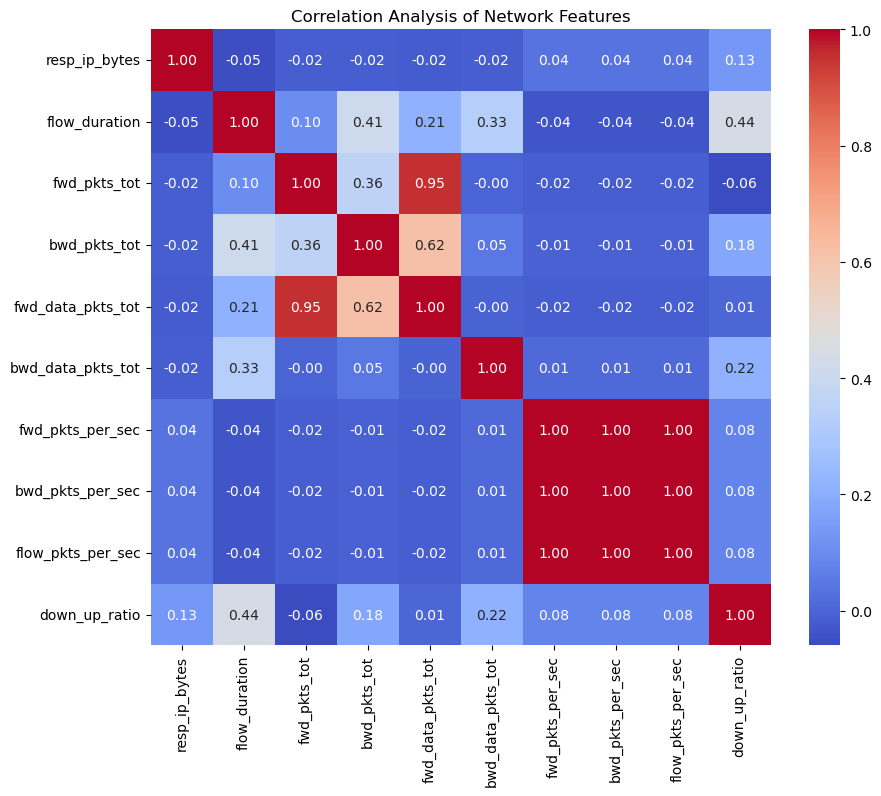

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = df2.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis of Network Features")
plt.show()

In [39]:
cols_to_remove = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec'] 
df_final = df_balanced.drop(columns=cols_to_remove)

print(f"Deleted{len(cols_to_remove)} Repeated columns")
print(f"Number of remaining features: {df_final.shape[1] - 1}")

Deleted2 Repeated columns
Number of remaining features: 90


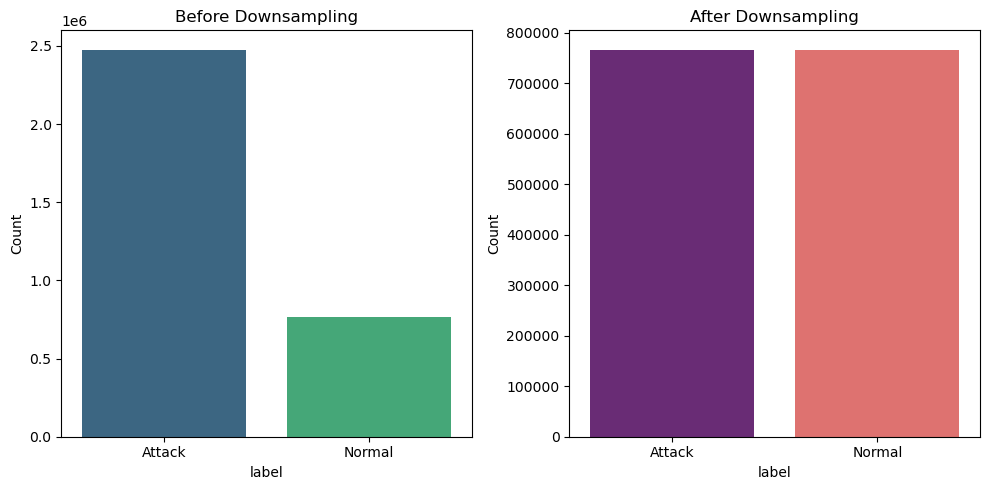

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

original_counts = df['label'].value_counts() 
balanced_counts = df_balanced['label'].value_counts()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=original_counts.index, y=original_counts.values, hue=original_counts.index, palette='viridis', legend=False)
plt.title('Before Downsampling')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.barplot(x=balanced_counts.index, y=balanced_counts.values, hue=balanced_counts.index, palette='magma', legend=False)
plt.title('After Downsampling')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [57]:
X_final = df_final.drop(columns=['label']).astype('float32')
y_final = le.transform(df_final['label'])
X_final_scaled = scaler.fit_transform(X_final)

X_train, X_test, y_train, y_test = train_test_split(X_final_scaled, y_final, test_size=0.2, random_state=42)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
print(X_train.shape)
print(X_test.shape)

(1227064, 1, 90)
(306766, 1, 90)


In [60]:
# اقتطاع 50% من البيانات المتوازنة عشوائياً
df_subset = df_balanced.sample(frac=0.5, random_state=42).reset_index(drop=True)

print(f"الحجم الجديد للبيانات: {len(df_subset)} سطر")
print("توزيع الفئات في العينة الجديدة:")
print(df_subset['label'].value_counts())

الحجم الجديد للبيانات: 766915 سطر
توزيع الفئات في العينة الجديدة:
label
Normal    383730
Attack    383185
Name: count, dtype: int64


#هذه الخريطة (Heatmap)

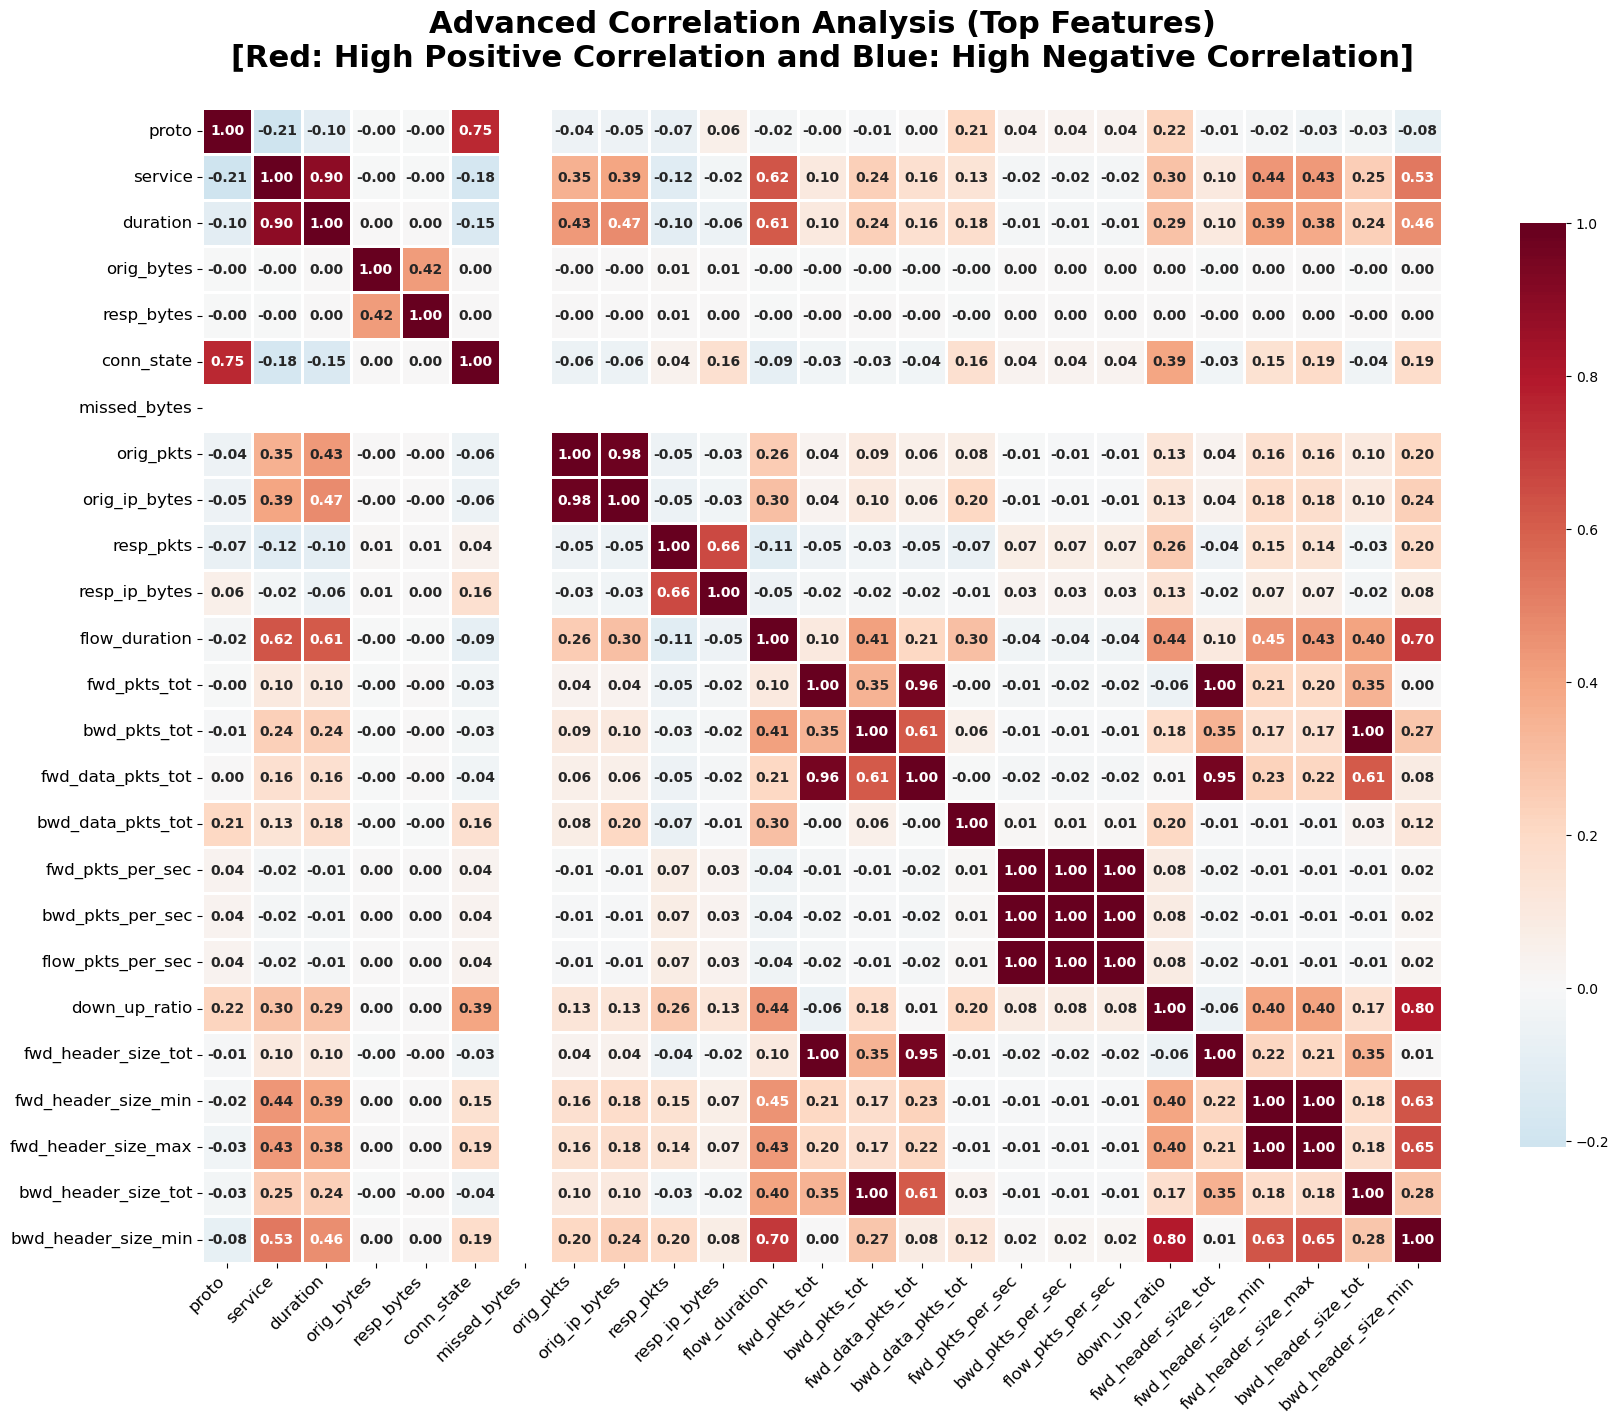

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top_features = df_subset.columns[:25] 
df_small = df_subset[top_features]

corr = df_small.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr, 
            annot=True,          
            fmt=".2f",           
            cmap='RdBu_r',      
            center=0,            
            linewidths=1,        
            cbar_kws={"shrink": .8},
            annot_kws={"size": 10, "weight": "bold"}) 

plt.title('Advanced Correlation Analysis (Top Features)\n[Red: High Positive Correlation and Blue: High Negative Correlation]', 
          fontsize=22, fontweight='bold', pad=30)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)

plt.show()

In [61]:
X_subset = df_subset.drop(columns=['label', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec'], errors='ignore').astype('float32')
y_subset = le.transform(df_subset['label'])

X_scaled = scaler.fit_transform(X_subset)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_subset, test_size=0.2, random_state=42)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [62]:
model = Sequential()
model.add(LSTM(8, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(Dropout(0.20))
model.add(LSTM(8, return_sequences=False))
model.add(Dropout(0.30))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test), verbose=1)

C:\Users\mah91\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9567 - loss: 0.1635 - val_accuracy: 0.9960 - val_loss: 0.0131
Epoch 2/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9979 - loss: 0.0155 - val_accuracy: 0.9990 - val_loss: 0.0070
Epoch 3/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9987 - loss: 0.0103 - val_accuracy: 0.9993 - val_loss: 0.0059
Epoch 4/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9990 - loss: 0.0085 - val_accuracy: 0.9993 - val_loss: 0.0059
Epoch 5/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9991 - loss: 0.0078 - val_accuracy: 0.9993 - val_loss: 0.0061


In [58]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# بناء موديل LSTM احترافي
model = Sequential()

# الطبقة الأولى: زيادة عدد الوحدات مع إضافة Regularization لمنع الـ Overfitting
model.add(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), 
               return_sequences=True,
               kernel_regularizer=regularizers.l2(0.001))) 
model.add(BatchNormalization())
model.add(Dropout(0.3)) # حذف 30% من الروابط عشوائياً لضمان التعلم الحقيقي

# الطبقة الثانية: لتبسيط الأنماط المستخلصة
model.add(LSTM(16, return_sequences=False))
model.add(Dropout(0.2))

# طبقات التصنيف النهائية
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Sigmoid للتصنيف الثنائي (Attack vs Normal)

# استخدام معدل تعلم (Learning Rate) متزن
optimizer = Adam(learning_rate=0.0005)

model.compile(loss='binary_crossentropy', 
              optimizer=optimizer, 
              metrics=['accuracy'])

model.summary()

C:\Users\mah91\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 1, 32)               │          15,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,153 (74.82 KB)

 Trainable params: 19,089 (74.57 KB)

 Non-trainable params: 64 (256.00 B)

In [59]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

history = model.fit(
    X_train, y_train, 
    epochs=5, 
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - accuracy: 0.9847 - loss: 0.0743 - val_accuracy: 0.9992 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 2/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9991 - loss: 0.0079 - val_accuracy: 0.9993 - val_loss: 0.0062 - learning_rate: 5.0000e-04
Epoch 3/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9992 - loss: 0.0066 - val_accuracy: 0.9993 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 4/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9993 - loss: 0.0056 - val_accuracy: 0.9994 - val_loss: 0.0048 - learning_rate: 5.0000e-04
Epoch 5/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9993 - loss: 0.0053 - val_accuracy: 0.9992 - val_loss: 0.0052 - learning_rate: 5.0000e-04


In [ ]:
train_data = model.evaluate(x_train,y_train,batch_size=128)
test_data = model.evaluate(x_test,y_test)
validation_data = model.evaluate(x_val,y_val)

print()
print('Train accuracy      = ',train_data[1])
print('Test accuracy       = ',test_data[1])
print('Validation accuracy = ',validation_data[1])

In [35]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int) # تحويل الاحتمالات إلى 0 أو 1

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Total Accuracy: {accuracy_score(y_test, y_pred):.4f}")

9587/9587 ━━━━━━━━━━━━━━━━━━━━ 7s 703us/step
Classification Report
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00    153806
      Normal       1.00      1.00      1.00    152960

    accuracy                           1.00    306766
   macro avg       1.00      1.00      1.00    306766
weighted avg       1.00      1.00      1.00    306766

Total Accuracy: 0.9988


#هنا النتيجة هو حساب عدد تنبؤات الموديل الصحيحة

In [84]:
#Specificity = TN / (TN + FP)
print('Model Specificity  = ',cm[1,1]/(cm[1,1]+cm[1,0]) )

Model Specificity  =  0.999739467993643


4794/4794 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step


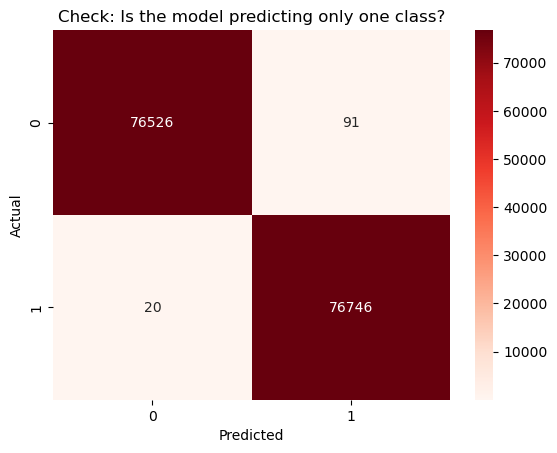

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_all = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_all)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Check: Is the model predicting only one class?')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

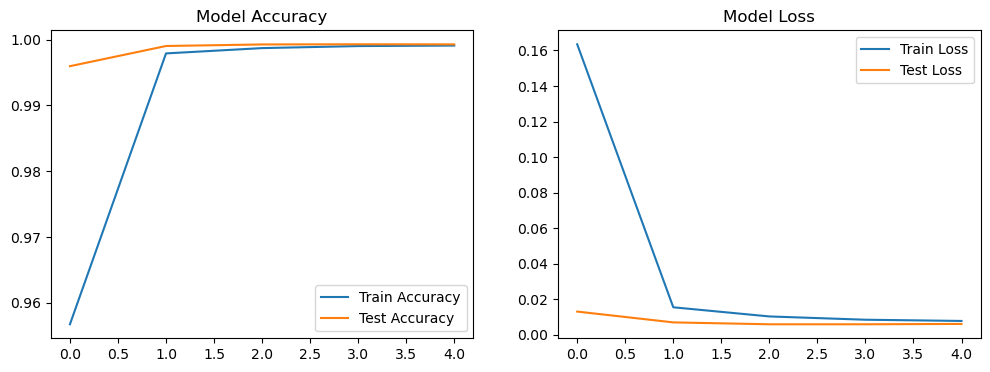

In [64]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [41]:
model.save('ids_lstm_model.keras')

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [87]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

model = load_model('ids_lstm_model.keras')
scaler = joblib.load('scaler.pkl')
le = joblib.load('label_encoder.pkl')

def predict_traffic_from_saved_model(sample_index):
    sample_to_predict = X_test[sample_index:sample_index+1]
    prediction_prob = model.predict(sample_to_predict, verbose=0)
    result_idx = (prediction_prob > 0.5).astype(int).flatten()[0]
    predicted_label = le.inverse_transform([result_idx])[0]
    actual_label = le.inverse_transform([y_test[sample_index]])[0]
    
    return predicted_label, actual_label

for i in range(33):  
    pred, actual = predict_traffic_from_saved_model(i)
    status = "Correct" if pred == actual else "Error"
    print(f"Sample {i:2}  Prediction: {pred:8}  Actual: {actual:8}  Status: {status}")

Sample  0  Prediction: Attack    Actual: Attack    Status: Correct
Sample  1  Prediction: Attack    Actual: Attack    Status: Correct
Sample  2  Prediction: Attack    Actual: Attack    Status: Correct
Sample  3  Prediction: Attack    Actual: Attack    Status: Correct
Sample  4  Prediction: Normal    Actual: Normal    Status: Correct
Sample  5  Prediction: Normal    Actual: Normal    Status: Correct
Sample  6  Prediction: Normal    Actual: Normal    Status: Correct
Sample  7  Prediction: Normal    Actual: Normal    Status: Correct
Sample  8  Prediction: Attack    Actual: Attack    Status: Correct
Sample  9  Prediction: Attack    Actual: Attack    Status: Correct
Sample 10  Prediction: Normal    Actual: Normal    Status: Correct
Sample 11  Prediction: Normal    Actual: Normal    Status: Correct
Sample 12  Prediction: Attack    Actual: Attack    Status: Correct
Sample 13  Prediction: Normal    Actual: Normal    Status: Correct
Sample 14  Prediction: Attack    Actual: Attack    Status: Cor